# Series resummation on the infinite 2d square lattice

In [52]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
import h5py
from robustpade import pade_approx, pade_approx_batch 

## Kubo 4th order benchmark

In [53]:

def X(beta, mu):
    return np.exp(beta * mu)

def XI(U, beta, mu):
    return 1 + 2 * X(beta, mu) + X(beta, mu)**2 * np.exp(-beta * U)

def GAMMA(U, beta, mu):
    return X(beta, mu) / XI(U, beta, mu)

def kubo_exact_2(U, beta, mu, t):
    # Exact order 2 result from Kubo
    gamma = GAMMA(U, beta, mu)
    return -4 * t**2 * (beta * (gamma - 2 * gamma**2) + 2/U * (1 - np.exp(-beta * U)) * gamma**2)

def kubo_exact_4(U, beta, mu, t):
    gamma = GAMMA(U, beta, mu)
    p4 = 1.0
    z = 4

    # Eq 13.3
    A_and_B = -z* (1/12 * beta**3 * (gamma - 2 * gamma**2) + 
                    4 * beta/U**2 * (1 + np.exp(-beta * U)) * gamma**2 - 
                    8/U**3 * (1 - np.exp(-beta * U)) * gamma**2)

    # Eq 13.4 (Fixed typos)
    C_and_D = -z*(z-1) * (1/6 * beta**3 * (gamma - 2 * gamma**2) + 
                     beta**2/U * (gamma**2 - 2 * (1 + np.exp(-beta * U)) * gamma**3) + 
                     2 * beta/U**2 * (np.exp(-beta * U) * gamma**2 + 2 * (1 - np.exp(-beta * U)) * gamma**3) - 
                     2/U**3 * (1 - np.exp(-beta * U)) * gamma**2)

    # Eq 13.5 (Fixed gamma**4 coefficient in the first line)
    E_1 = 2/3 * beta**3 * (gamma - 10 * gamma**2 + (29 - 3 * np.exp(-beta * U)) * gamma**3 - (26 - 14 * np.exp(-beta * U)) * gamma**4) + \
          8 * beta**2/U * (gamma**2 - (5 - np.exp(-beta * U)) * gamma**3 + 6 * (1 - np.exp(-beta * U)) * gamma**4) 

    E_2 = 8 * beta/U**2 * (-2 * gamma**2 + (9 + np.exp(-beta * U)) * gamma**3 - 10 * (1 - np.exp(-beta * U)) * gamma**4) + \
          16/U**3 * (1 - np.exp(-beta * U)) * (gamma**2 - 5 * gamma**3 + 5 * (1 - np.exp(-beta * U)) * gamma**4)

    E = -p4 * (E_1 + E_2)

    # Eq 13.6
    F = z*(2*z-1) * (beta**3 * (gamma - 2 * gamma**2)**2 + 
              4 * beta**2/U * (1 - np.exp(-beta * U)) * (gamma**3 - 2 * gamma**4) + 
              4 * beta/U**2 * (1 - np.exp(-beta * U))**2 * gamma**4)

    return t**4 * (A_and_B + C_and_D + E + F)

In [54]:
def Z_atomic(U:float, beta:float, mu:float):

    return 1+2*np.exp(beta*mu)+np.exp(beta*(2*mu - U))


def a_0(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)
    return -1/beta*np.log(Zat) # factor 2 for spin and


def a_2(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)
    return -2/beta*fact*(A+B)*4 #factor 2 for spin and 2 for sites!


## $U = 8.0$ $\beta=0.75$ mu scan

In [55]:
U = 8.0
beta = 0.75

In [58]:
#load order4
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_4_scan_mu_U=8.0_beta=75.0_alpha=0.01.h5', 'r') as f:
    mus = f['mu_list'][:]
    means_4 = f['mean_list'][:]
    errors_4 = f['error_list'][:]

#load order 6
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_6_scan_mu_U=8.0_beta=75.0_alpha=0.01.h5', 'r') as f:
    mus_62 = f['mu_list'][:]
    means_6 = f['mean_list'][:]
    errors_6 = f['error_list'][:]

In [60]:
a4 = means_4
a6 = means_6

In [67]:
errors_6/means_6

array([-0.01904637, -0.01813286, -0.01859976, -0.02180548, -0.02869098,
       -0.020373  , -0.02634912, -0.04070877, -0.12188336,  0.09679675,
        0.0337598 ,  0.02095136,  0.01539615,  0.01182918,  0.00926592,
        0.00806493,  0.00722816,  0.00665426,  0.00617582,  0.00589818,
        0.00555551,  0.00529827,  0.00520228,  0.00504934,  0.00502318,
        0.00501565,  0.00490813,  0.00492608,  0.00492295,  0.00496679,
        0.0050395 ,  0.00504752,  0.00505051,  0.00532703,  0.00564182,
        0.00591142,  0.00640864,  0.00726222,  0.00811092,  0.01039528,
        0.01502989,  0.0387403 , -0.05244281, -0.01681381, -0.0105034 ,
       -0.00794398, -0.00681682, -0.00641436, -0.00638324, -0.00669231])

In [61]:

naive_sum_4 = lambda t: a_0(U,beta, mus) + a_2(U, beta, mus)*t**2 + a4*t**4
naive_sum_6 = lambda t: a_0(U,beta, mus) + a_2(U, beta, mus)*t**2 + a4*t**4 + a6*t**6
naive_sum_4_kubo = lambda t: a_0(U,beta,mus) + a_2(U,beta,mus)*t**2+ kubo_exact_4(U, beta, mus, t)

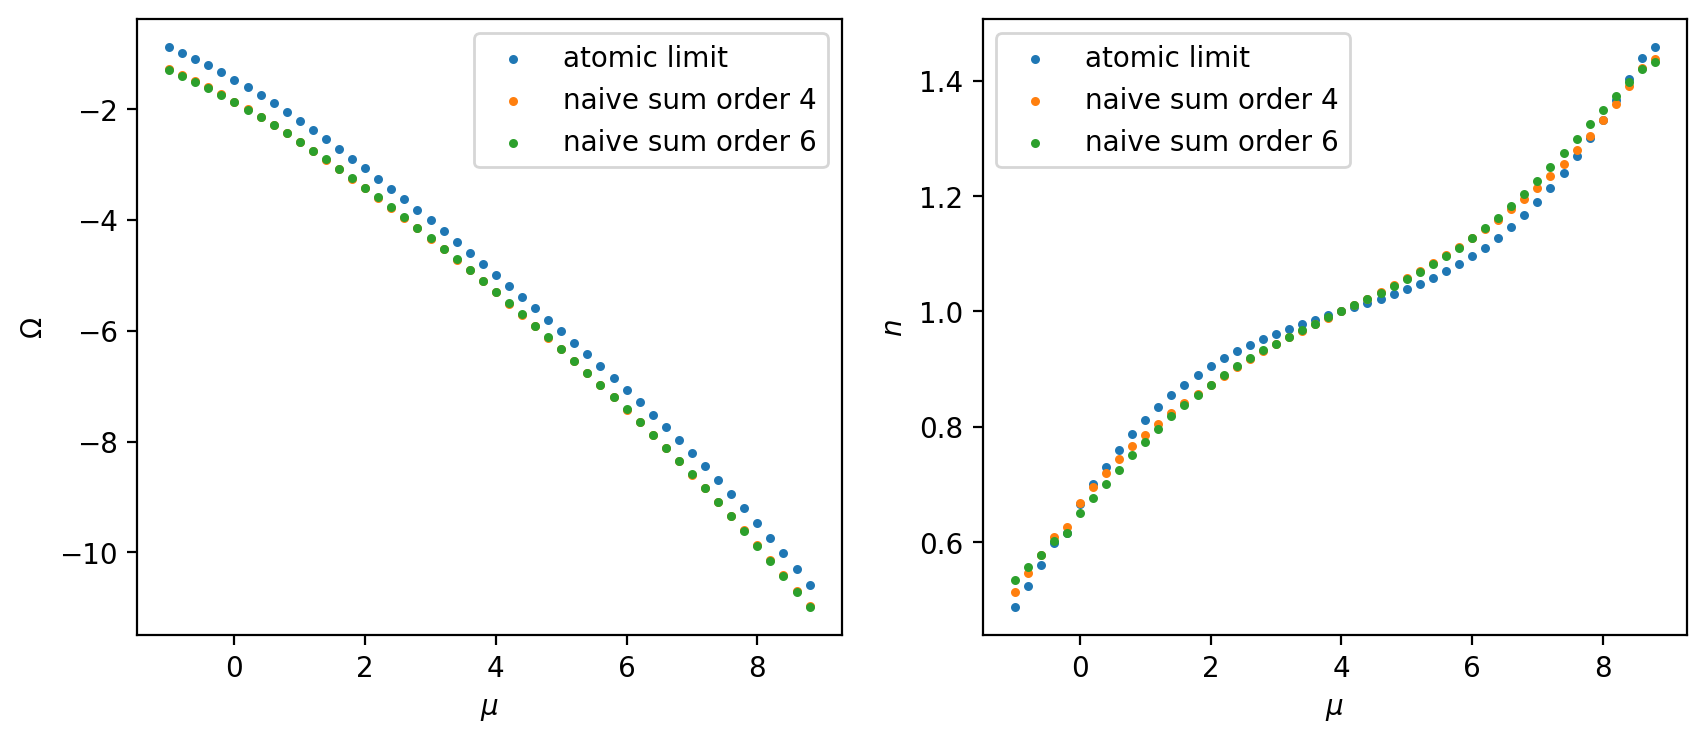

In [73]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
t = 1.0
ax1.scatter(mus, a_0(U,beta,mus), label='atomic limit', s=5)
ax1.scatter(mus, naive_sum_4(t), label='naive sum order 4', s=5)
ax1.scatter(mus, naive_sum_6(t), label='naive sum order 6', s=5)

ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel(r'$\Omega$')
ax1.legend()

ax2.scatter(mus, -np.gradient(a_0(U,beta,mus), mus), label='atomic limit', s=5)
ax2.scatter(mus, -np.gradient(naive_sum_4(t), mus), label='naive sum order 4', s=5)
ax2.scatter(mus, -np.gradient(naive_sum_6(t), mus), label='naive sum order 6', s=5)
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel(r'$n$')
ax2.legend()

In [64]:
Cdet = np.array([0.000000000000000000e+00, 6.577886434859689935e-01,
2.000000000000000111e-01, 6.830654739026462696e-01,
4.000000000000000222e-01, 7.076495052411750919e-01,
6.000000000000000888e-01, 7.314561757479093318e-01,
8.000000000000000444e-01, 7.544149325723877864e-01,
1.000000000000000000e+00, 7.764680082055557264e-01,
1.200000000000000178e+00, 7.975690887248386707e-01,
1.400000000000000133e+00, 8.176829680520789623e-01,
1.600000000000000089e+00, 8.367864676447966943e-01,
1.800000000000000044e+00, 8.548702023276939510e-01,
2.000000000000000000e+00, 8.719404788084273994e-01,
2.200000000000000178e+00, 8.880207016779730900e-01,
2.400000000000000355e+00, 9.031519434244016376e-01,
2.600000000000000089e+00, 9.173926215565577635e-01,
2.800000000000000266e+00, 9.308174158122632935e-01,
3.000000000000000000e+00, 9.435156370374528922e-01,
3.200000000000000178e+00, 9.555892585948051465e-01,
3.400000000000000355e+00, 9.671507808392967309e-01,
3.600000000000000089e+00, 9.783210477561885554e-01,
3.800000000000000266e+00, 9.892270864443353240e-01,
4.000000000000000000e+00, 9.999999999999955591e-01])

In [65]:
Cdet_mus = Cdet[::2]
Cdet_values = Cdet[1::2]

Text(0.5, 1.0, 'Density vs chemical potential $U=8$, $\\beta=0.75$')

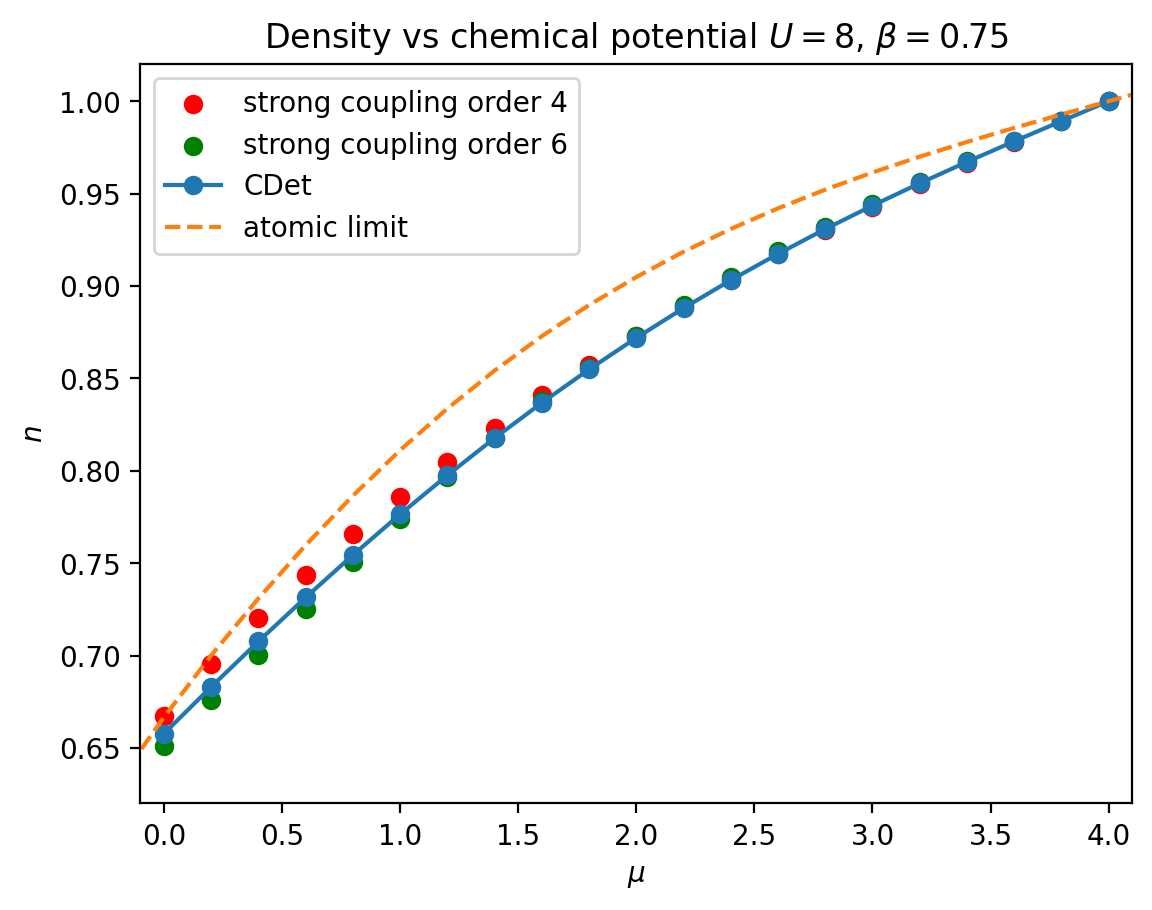

In [74]:
plt.scatter(mus, -np.gradient(naive_sum_4(1.0), mus), label='strong coupling order 4', c='r', zorder=2)
plt.scatter(mus, -np.gradient(naive_sum_6(1.0), mus), label='strong coupling order 6', c='g', zorder=2)

plt.plot(Cdet_mus, Cdet_values, marker = 'o', label = 'CDet')
plt.plot(mus, -np.gradient(a_0(U,beta,mus), mus), linestyle='dashed', label='atomic limit')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$n$')
plt.legend()
plt.xlim(-0.1, 4.1)
plt.ylim(0.62, 1.02)
plt.title(r'Density vs chemical potential $U=8$, $\beta=0.75$')